In [1]:
!pip install kaggle wandb -Uq
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!rm -rf ~/.kaggle
!mkdir ~/.kaggle
!cp "/content/drive/MyDrive/Colab Notebooks/kaggle_API_credentials/kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d fer2013

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)
replace fer2013/example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace fer2013/fer2013.tar.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace fer2013/icml_face_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace fer2013/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace fer2013/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [4]:
from google.colab import userdata
wandb_key = userdata.get('WANDB_API_KEY')

import wandb
wandb.login(key=wandb_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ngval22 (ngval22-s) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [6]:
df = pd.read_csv('./fer2013/train.csv')

train_val_df, test_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df['emotion']
)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.111, random_state=42, stratify=train_val_df['emotion']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 22969, Val: 2869, Test: 2871


In [7]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(7),
    y=train_df['emotion'].values
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print("Class weights:", class_weights)

Class weights: [1.026364   9.42898194 1.00100235 0.56848332 0.84919403 1.29337237
 0.82589623]


In [8]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        pixels = np.array(row['pixels'].split(' '), dtype=np.uint8).reshape(48, 48)
        image = Image.fromarray(pixels, mode='L')
        if self.transform:
            image = self.transform(image)
        label = int(row['emotion'])
        return image, label

In [9]:
# mean and std computed from EDA notebook: 0.5077, 0.2550
# using those exact values here instead of generic 0.5

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(48, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5077], std=[0.2550])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5077], std=[0.2550])
])

In [10]:
BATCH_SIZE = 64

train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset   = FERDataset(val_df,   transform=val_transform)
test_dataset  = FERDataset(test_df,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# sanity check
imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}, Labels shape: {labels.shape}")

/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')


Batch shape: torch.Size([64, 1, 48, 48]), Labels shape: torch.Size([64])


In [11]:
class BaselineCNN(nn.Module):
    """
    Baseline: 2 conv layers, no BatchNorm, no Dropout.
    Purpose: establish a minimum performance floor.
    Expected to underfit — that finding justifies adding depth in arch2.
    """
    def __init__(self, num_classes=7):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 48x48 -> 48x48
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 48x48 -> 24x24

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 24x24 -> 24x24
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 24x24 -> 12x12
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=7).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=7, bias=True)
  )
)

Trainable parameters: 2,380,167


In [12]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [13]:
config = {
    "architecture": "BaselineCNN",
    "epochs": 30,
    "batch_size": BATCH_SIZE,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss with class weights",
    "num_conv_layers": 2,
    "dropout": False,
    "batch_norm": False,
    "notes": "Baseline — minimal arch to establish floor. No regularization intentionally."
}

run = wandb.init(
    project="facial-expression-recognition",
    name="arch1-baseline-cnn",
    group="arch1-baseline",
    config=config
)

model = BaselineCNN(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])

best_val_acc = 0.0

for epoch in range(config['epochs']):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = evaluate(model, val_loader, criterion)

    wandb.log({
        "epoch":      epoch + 1,
        "train_loss": train_loss,
        "train_acc":  train_acc,
        "val_loss":   val_loss,
        "val_acc":    val_acc,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_baseline_cnn.pth')

    print(f"Epoch {epoch+1:02d}/{config['epochs']} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')


Epoch 01/30 | Train Loss: 1.9152 Acc: 0.2042 | Val Loss: 1.8352 Acc: 0.2496


/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')


Epoch 02/30 | Train Loss: 1.8394 Acc: 0.2717 | Val Loss: 1.7413 Acc: 0.3447


/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')


...

Epoch 28/30 | Train Loss: 1.3659 Acc: 0.4754 | Val Loss: 1.3887 Acc: 0.4981


/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')


Epoch 29/30 | Train Loss: 1.3592 Acc: 0.4752 | Val Loss: 1.3739 Acc: 0.4838


/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')


Epoch 30/30 | Train Loss: 1.3574 Acc: 0.4757 | Val Loss: 1.3640 Acc: 0.4988

Best Val Accuracy: 0.5016


In [14]:
# load best checkpoint and evaluate on held-out test set
model.load_state_dict(torch.load('best_baseline_cnn.pth'))
test_loss, test_acc = evaluate(model, test_loader, criterion)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

wandb.log({
    "test_loss": test_loss,
    "test_acc":  test_acc,
    "best_val_acc": best_val_acc
})

/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')


Test Loss: 1.3822 | Test Accuracy: 0.5012


In [15]:
model.eval()
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
class_correct = [0] * 7
class_total   = [0] * 7

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        for label, pred in zip(labels, predicted):
            class_correct[label] += (pred == label).item()
            class_total[label]   += 1

per_class = {}
print(f"{'Class':<12} {'Correct':<10} {'Total':<10} {'Accuracy'}")
print("-" * 42)
for i, name in enumerate(emotion_labels):
    acc = class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    per_class[f"test_acc_{name.lower()}"] = acc
    print(f"{name:<12} {class_correct[i]:<10} {class_total[i]:<10} {acc:.4f}")

wandb.log(per_class)

/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')


Class        Correct    Total      Accuracy
------------------------------------------
Angry        188        399        0.4712
Disgust      24         44         0.5455
Fear         79         410        0.1927
Happy        545        722        0.7548
Sad          135        483        0.2795
Surprise     196        317        0.6183
Neutral      272        496        0.5484


/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipykernel_5520/321444239.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')


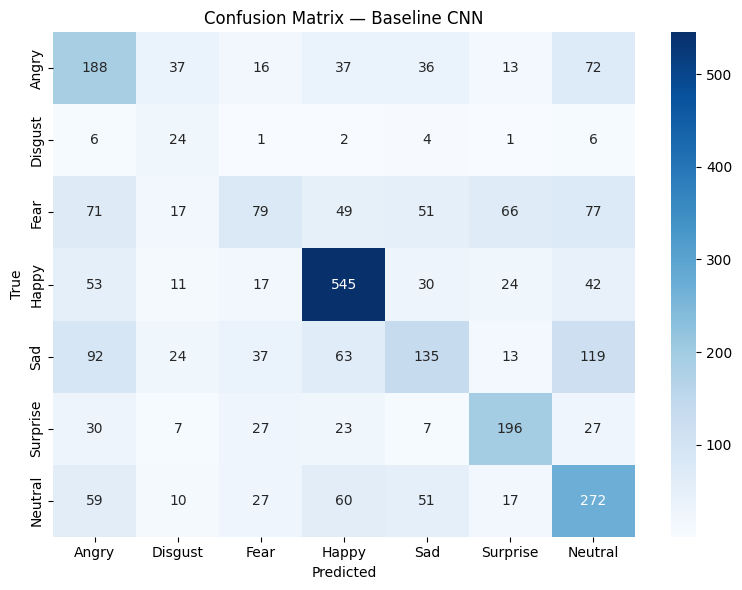

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotion_labels,
            yticklabels=emotion_labels, cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Baseline CNN')
plt.tight_layout()

wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.show()

In [17]:
wandb.summary['best_val_acc'] = best_val_acc
wandb.summary['test_acc']     = test_acc
wandb.finish()

print("""
=== BASELINE FINDINGS ===
- 2 conv layers, no BatchNorm, no Dropout
- Observe whether train_acc >> val_acc (overfitting) or both low (underfitting)
- If underfitting: next step is adding more conv layers (arch2)
- If overfitting: next step is adding BatchNorm + Dropout (arch2)
- Per-class: expect Disgust to perform worst due to 16x class imbalance
- These findings directly motivate arch2 decisions — document in README
""")

best_val_acc,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test_acc,▁
test_acc_angry,▁
test_acc_disgust,▁
test_acc_fear,▁
test_acc_happy,▁
test_acc_neutral,▁
test_acc_sad,▁
test_acc_surprise,▁
+5,...



=== BASELINE FINDINGS ===
- 2 conv layers, no BatchNorm, no Dropout
- Observe whether train_acc >> val_acc (overfitting) or both low (underfitting)
- If underfitting: next step is adding more conv layers (arch2)
- If overfitting: next step is adding BatchNorm + Dropout (arch2)
- Per-class: expect Disgust to perform worst due to 16x class imbalance
- These findings directly motivate arch2 decisions — document in README

